# Exploratory Data Analysis (EDA)

**Project**: Bati Bank Credit Risk Model
**Dataset**: Xente Fraud Detection Challenge (~140,000 transactions, Nov 2018 – Mar 2019)
**Author**: Bati Bank Analytics Team

This notebook explores the Xente transaction dataset to uncover patterns, identify data quality issues, and form hypotheses to guide feature engineering for the credit risk model.

In [1]:
# Standard library imports
import os
import sys
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
Pandas version: 2.3.3
NumPy version: 2.4.6


## 1. Data Overview

Load the raw transaction data and inspect its structure, including shape, column names, and data types.

In [2]:
# Define data path (adjust as needed)
DATA_PATH = '../data/raw/data.csv'

def load_data(filepath):
    """
    Load transaction data.
    """
    df = pd.read_csv(filepath)
    print(f"✅ Data loaded successfully from: {filepath}")
    return df

# Load the dataset
df = load_data(DATA_PATH)

if df is not None:
    print(f"Dataset Shape: {df.shape}")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

✅ Data loaded successfully from: ../data/raw/data.csv
Dataset Shape: (95662, 16)
Rows: 95,662
Columns: 16


In [3]:
# Display column information

print("=== Column Names and Data Types ===")
print("=" * 38)
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'DataType': df.dtypes.values,
    'NonNullCount': df.count().values,
    'NullCount': df.isnull().sum().values,
    'NullPct': (df.isnull().sum() / len(df) * 100).round(2).values,
    'UniqueValues': df.nunique().values,
    'SampleValue': [str(df[col].iloc[0]) if len(df) > 0 else 'N/A' for col in df.columns]})
display(dtype_df)

print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== Column Names and Data Types ===


,Column,DataType,NonNullCount,NullCount,NullPct,UniqueValues,SampleValue
0,TransactionId,object,95662,0,0.0,95662,TransactionId_76871
1,BatchId,object,95662,0,0.0,94809,BatchId_36123
2,AccountId,object,95662,0,0.0,3633,AccountId_3957
3,SubscriptionId,object,95662,0,0.0,3627,SubscriptionId_887
4,CustomerId,object,95662,0,0.0,3742,CustomerId_4406
5,CurrencyCode,object,95662,0,0.0,1,UGX
6,CountryCode,int64,95662,0,0.0,1,256
7,ProviderId,object,95662,0,0.0,6,ProviderId_6
8,ProductId,object,95662,0,0.0,23,ProductId_10
9,ProductCategory,object,95662,0,0.0,9,airtime


Memory Usage: 74.51 MB


In [4]:
# Quick peek at the data
print("=== First 5 Rows ===")
display(df.head())

print("=== Last 5 Rows ===")
display(df.tail())

=== First 5 Rows ===


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


=== Last 5 Rows ===


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
95657,TransactionId_89881,BatchId_96668,AccountId_4841,SubscriptionId_3829,CustomerId_3078,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-1000.0,1000,2019-02-13T09:54:09Z,2,0
95658,TransactionId_91597,BatchId_3503,AccountId_3439,SubscriptionId_2643,CustomerId_3874,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2019-02-13T09:54:25Z,2,0
95659,TransactionId_82501,BatchId_118602,AccountId_4841,SubscriptionId_3829,CustomerId_3874,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2019-02-13T09:54:35Z,2,0
95660,TransactionId_136354,BatchId_70924,AccountId_1346,SubscriptionId_652,CustomerId_1709,UGX,256,ProviderId_6,ProductId_19,tv,ChannelId_3,3000.0,3000,2019-02-13T10:01:10Z,2,0
95661,TransactionId_35670,BatchId_29317,AccountId_4841,SubscriptionId_3829,CustomerId_1709,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-60.0,60,2019-02-13T10:01:28Z,2,0


## 2. Summary Statistics

Understand the central tendency, dispersion, and shape of the dataset's distribution.

In [5]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID columns from numerical analysis
id_patterns = ['Id', 'ID', 'id']
analysis_cols = [col for col in numerical_cols if not any(pattern in col for pattern in id_patterns)]

print(f"Numerical columns for analysis: {analysis_cols}")

if analysis_cols:
    print("=== Descriptive Statistics ===")
    desc_stats = df[analysis_cols].describe().T

    # Add additional statistics
    desc_stats['skewness'] = df[analysis_cols].skew()
    desc_stats['kurtosis'] = df[analysis_cols].kurtosis()
    desc_stats['range'] = desc_stats['max'] - desc_stats['min']
    desc_stats['iqr'] = desc_stats['75%'] - desc_stats['25%']
    desc_stats['cv'] = (desc_stats['std'] / desc_stats['mean']).replace([np.inf, -np.inf], np.nan)

    display(desc_stats.round(4))
else:
    print("No suitable numerical columns found for analysis.")

Numerical columns for analysis: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,range,iqr,cv
CountryCode,95662.0,256.0000,0.0000,256.0,256.0,256.0,256.0,256.0,0.0000,0.0000,0.0,0.0,0.0000
Amount,95662.0,6717.8464,123306.7972,-1000000.0,-50.0,1000.0,2800.0,9880000.0,51.0985,3363.1277,10880000.0,2850.0,18.3551
Value,95662.0,9900.5839,123122.0878,2.0,275.0,1000.0,5000.0,9880000.0,51.2911,3378.0693,9879998.0,4725.0,12.4358
PricingStrategy,95662.0,2.2560,0.7329,0.0,2.0,2.0,2.0,4.0,1.6591,2.0875,4.0,0.0,0.3249
FraudResult,95662.0,0.0020,0.0449,0.0,0.0,0.0,0.0,1.0,22.1963,490.6858,1.0,0.0,22.2410


In [6]:
# Additional statistics for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

if categorical_cols:
    print("=== Categorical Column Summary ===")
    for col in categorical_cols:
        print(f"--- {col} ---")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Most frequent: {df[col].mode().iloc[0] if not df[col].mode().empty else 'N/A'}")
        print(f"  Top 5 values:")
        print(df[col].value_counts().head().to_string().replace('', ''))

Categorical columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']
=== Categorical Column Summary ===
--- TransactionId ---
  Unique values: 95662
  Most frequent: TransactionId_1
  Top 5 values:
TransactionId
TransactionId_76871    1
TransactionId_73770    1
TransactionId_26203    1
TransactionId_380      1
TransactionId_28195    1
--- BatchId ---
  Unique values: 94809
  Most frequent: BatchId_67019
  Top 5 values:
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
--- AccountId ---
  Unique values: 3633
  Most frequent: AccountId_4841
  Top 5 values:
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
--- SubscriptionId ---
  Unique values: 3627
  Most frequent: SubscriptionId_3829
  Top 5 values:
SubscriptionId
Subscrip

## 3. Distribution of Numerical Features

Visualize the distribution of numerical features to identify patterns, skewness, and potential outliers.

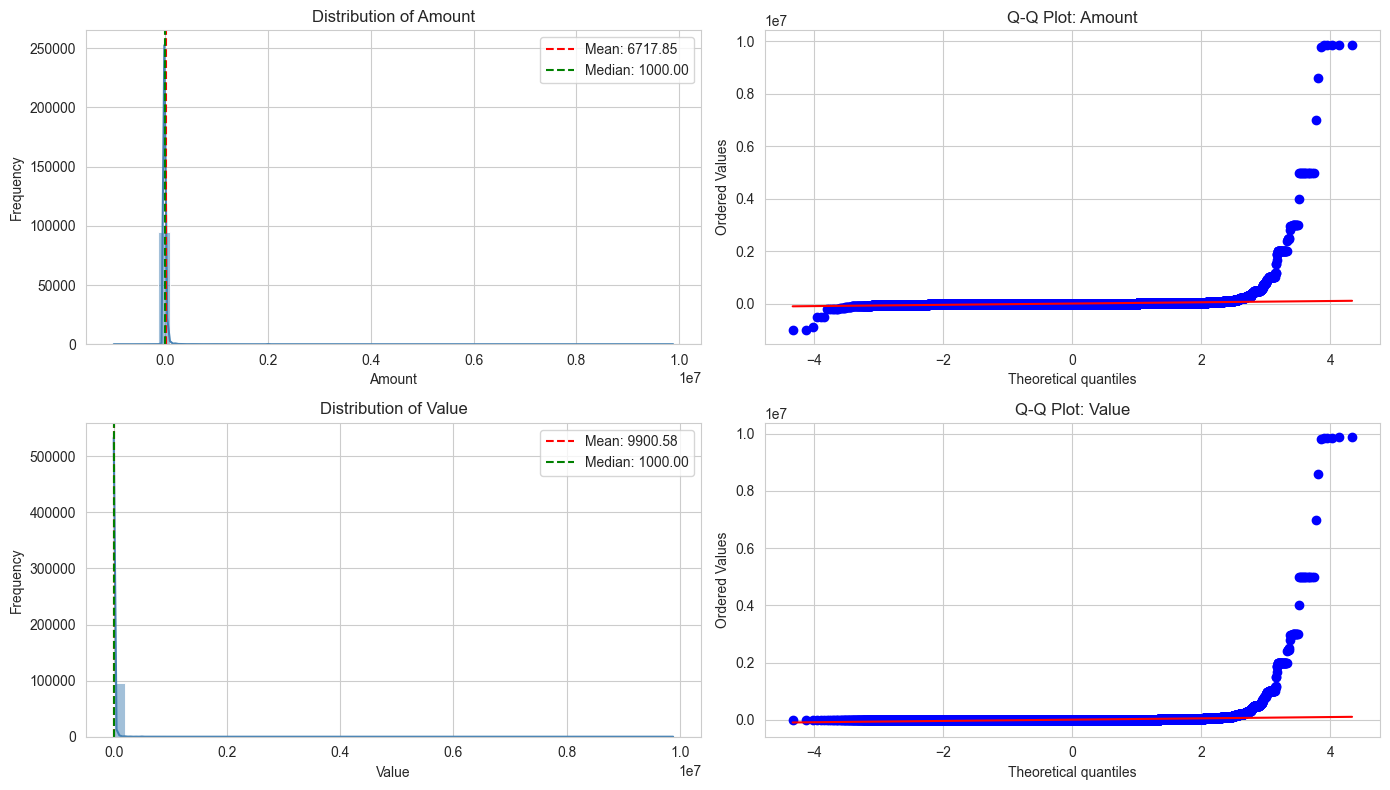

📊 Skewness Analysis:
  Amount: 51.098 (highly right-skewed)
  Value: 51.291 (highly right-skewed)


In [8]:
if df is not None and analysis_cols:
    # Select key numerical columns for visualization
    key_numerical = [col for col in analysis_cols if col in ['Amount', 'Value']]
    if not key_numerical and analysis_cols:
        key_numerical = analysis_cols[:4]  # Take first 4 if specific columns not found

    n_cols = len(key_numerical)
    fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))

    if n_cols == 1:
        axes = axes.reshape(1, -1)

    for idx, col in enumerate(key_numerical):
        # Histogram with KDE
        ax1 = axes[idx, 0]
        sns.histplot(df[col], kde=True, bins=50, ax=ax1, color='steelblue')
        ax1.set_title(f'Distribution of {col}')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Frequency')

        # Add statistics text
        mean_val = df[col].mean()
        median_val = df[col].median()
        ax1.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        ax1.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
        ax1.legend()

        # Q-Q plot for normality assessment
        ax2 = axes[idx, 1]
        stats.probplot(df[col].dropna(), dist="norm", plot=ax2)
        ax2.set_title(f'Q-Q Plot: {col}')

    plt.tight_layout()
    plt.savefig('../notebooks/numerical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"📊 Skewness Analysis:")
    for col in key_numerical:
        skew = df[col].skew()
        skew_desc = "highly right-skewed" if skew > 1 else "moderately right-skewed" if skew > 0.5 else "approximately symmetric" if abs(skew) < 0.5 else "left-skewed"
        print(f"  {col}: {skew:.3f} ({skew_desc})")

Applying log transformation to highly skewed columns: ['Amount', 'Value', 'PricingStrategy', 'FraudResult']


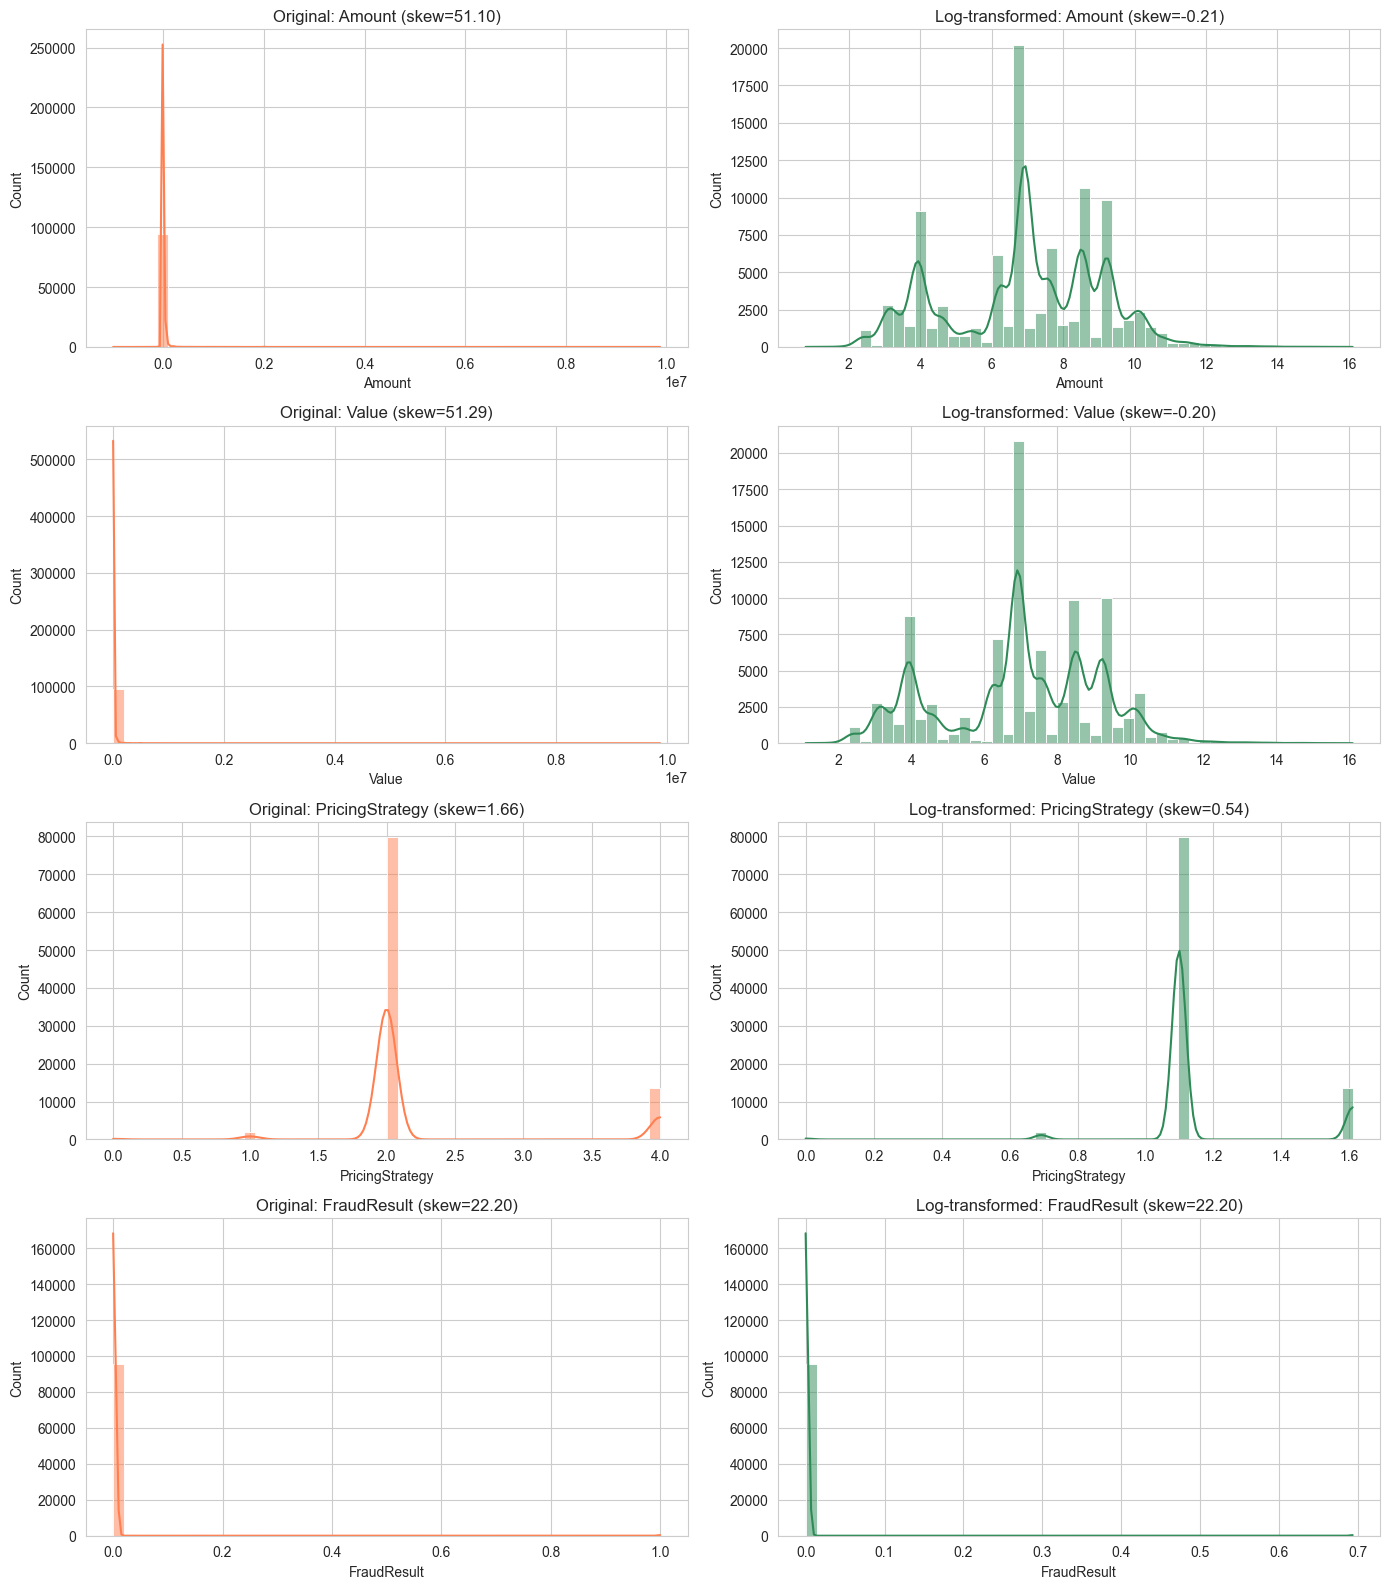

In [9]:
# Log-transformed distributions for highly skewed data
if df is not None and analysis_cols:
    highly_skewed = [col for col in analysis_cols if abs(df[col].skew()) > 1]

    if highly_skewed:
        print(f"Applying log transformation to highly skewed columns: {highly_skewed}")

        fig, axes = plt.subplots(len(highly_skewed), 2, figsize=(14, 4 * len(highly_skewed)))

        if len(highly_skewed) == 1:
            axes = axes.reshape(1, -1)

        for idx, col in enumerate(highly_skewed):
            # Original
            ax1 = axes[idx, 0]
            sns.histplot(df[col], kde=True, bins=50, ax=ax1, color='coral')
            ax1.set_title(f'Original: {col} (skew={df[col].skew():.2f})')

            # Log-transformed (handle negative values)
            ax2 = axes[idx, 1]
            log_data = np.log1p(df[col].abs())
            sns.histplot(log_data, kde=True, bins=50, ax=ax2, color='seagreen')
            ax2.set_title(f'Log-transformed: {col} (skew={log_data.skew():.2f})')

        plt.tight_layout()
        plt.savefig('../notebooks/log_transformed_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()

## 4. Distribution of Categorical Features

Analyzing the distribution of categorical features provides insights into the frequency and variability of categories.

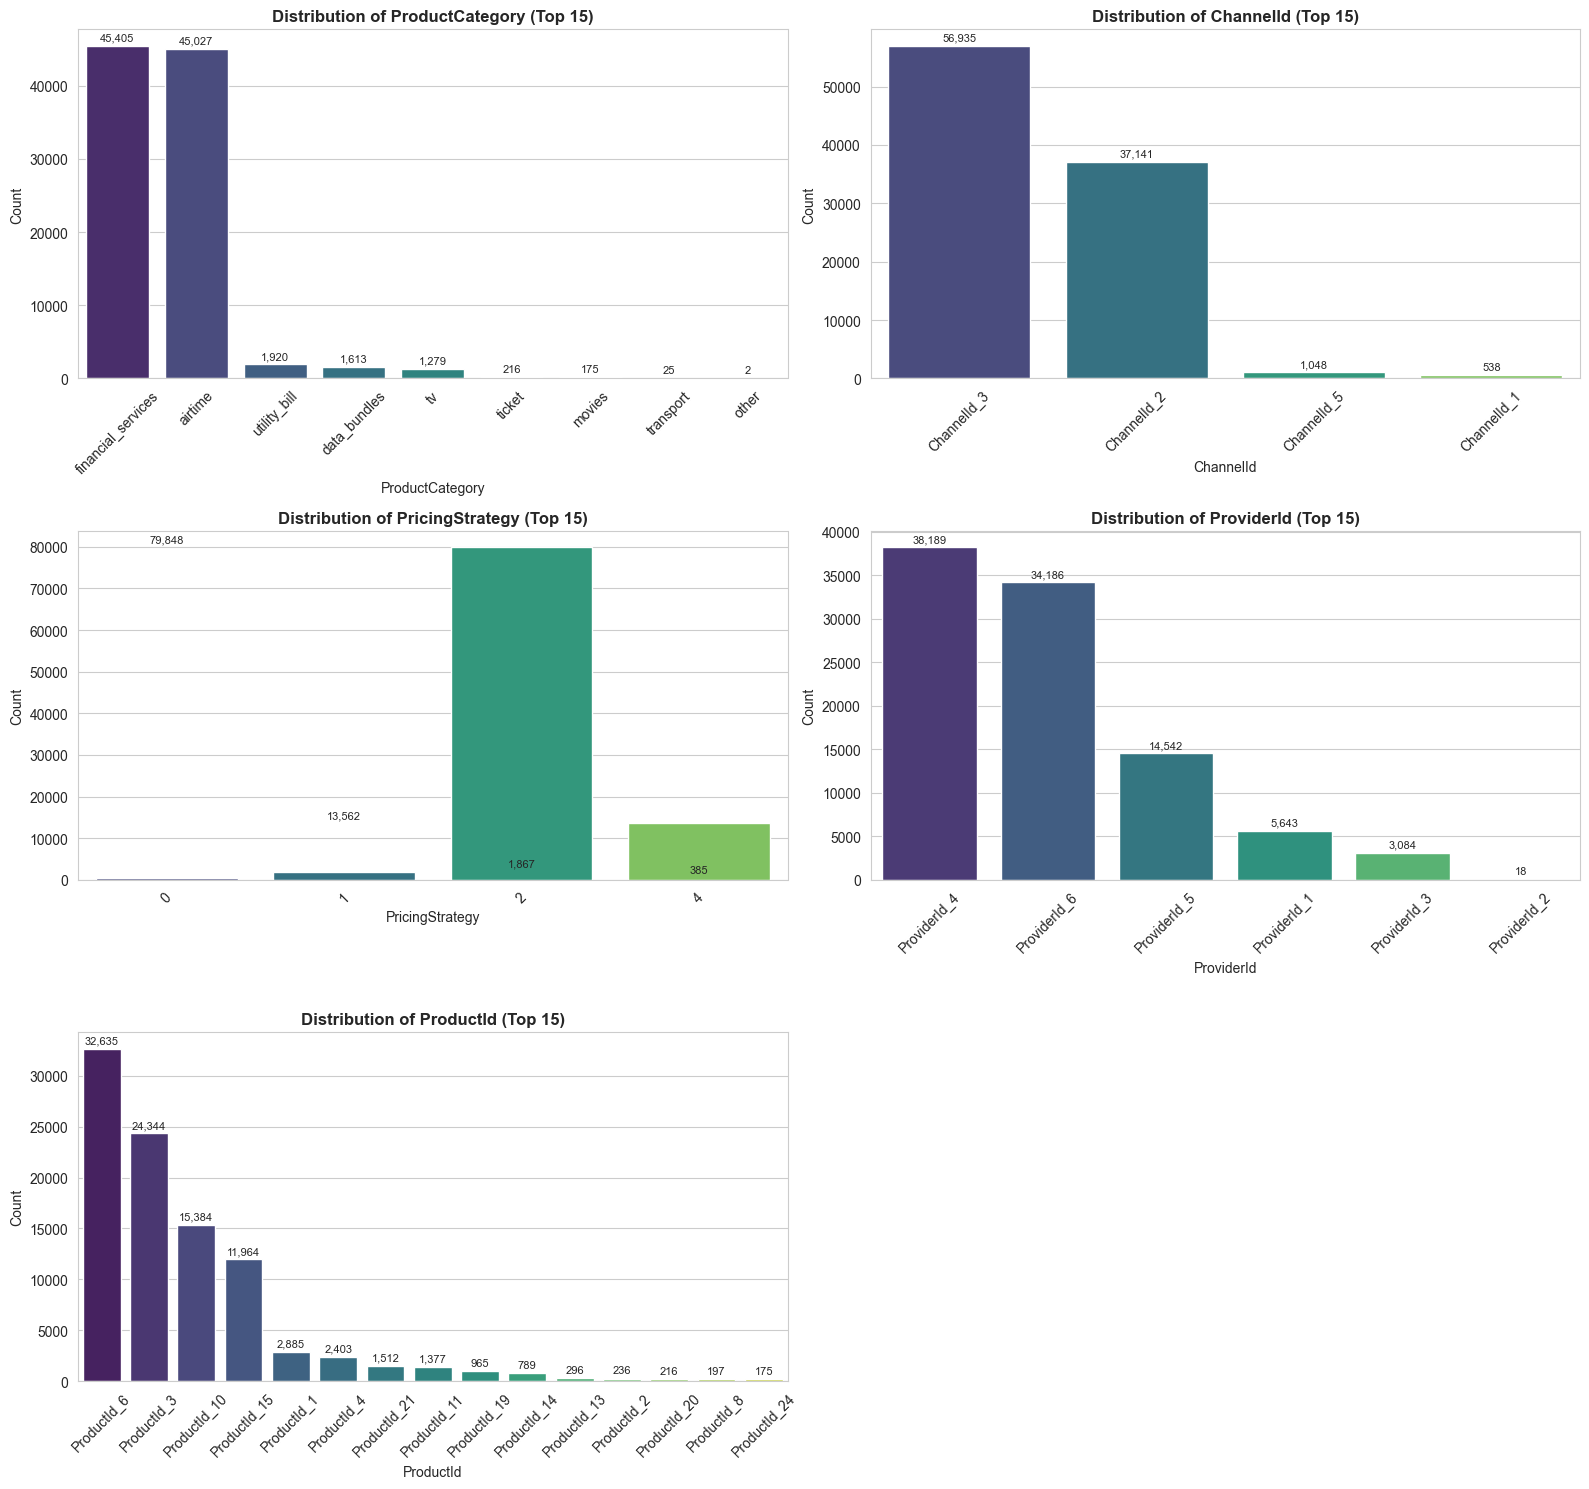

=== Categorical Feature Statistics ===
ProductCategory:
  Unique categories: 9
  Top category: financial_services (47.5%)
  Category concentration: 47.5% in top category

ChannelId:
  Unique categories: 4
  Top category: ChannelId_3 (59.5%)
  Category concentration: 59.5% in top category

PricingStrategy:
  Unique categories: 4
  Top category: 2 (83.5%)
  Category concentration: 83.5% in top category

ProviderId:
  Unique categories: 6
  Top category: ProviderId_4 (39.9%)
  Category concentration: 39.9% in top category

ProductId:
  Unique categories: 23
  Top category: ProductId_6 (34.1%)
  Category concentration: 34.1% in top category



In [10]:
if df is not None:
    # Identify key categorical columns based on the Xente dataset schema
    expected_categorical = ['ProductCategory', 'ChannelId', 'PricingStrategy', 'ProviderId', 'ProductId']
    available_categorical = [col for col in expected_categorical if col in df.columns]

    if not available_categorical and categorical_cols:
        available_categorical = categorical_cols[:5]

    if available_categorical:
        n_cat = len(available_categorical)
        fig, axes = plt.subplots((n_cat + 1) // 2, 2, figsize=(16, 5 * ((n_cat + 1) // 2)))
        axes = axes.flatten() if n_cat > 1 else [axes]

        for idx, col in enumerate(available_categorical):
            value_counts = df[col].value_counts().head(15)  # Top 15 categories

            sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[idx], palette='viridis')
            axes[idx].set_title(f'Distribution of {col} (Top 15)', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Count')
            axes[idx].tick_params(axis='x', rotation=45)

            # Add count labels on bars
            for i, v in enumerate(value_counts.values):
                axes[idx].text(i, v + max(value_counts.values) * 0.01, f'{v:,}', 
                             ha='center', va='bottom', fontsize=8)

        # Hide unused subplots
        for idx in range(n_cat, len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.savefig('../notebooks/categorical_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Print category statistics
        print("=== Categorical Feature Statistics ===")
        for col in available_categorical:
            n_unique = df[col].nunique()
            top_cat = df[col].value_counts().iloc[0]
            top_pct = (top_cat / len(df)) * 100
            print(f"{col}:")
            print(f"  Unique categories: {n_unique}")
            print(f"  Top category: {df[col].value_counts().index[0]} ({top_pct:.1f}%)")
            print(f"  Category concentration: {top_pct:.1f}% in top category")
            print()

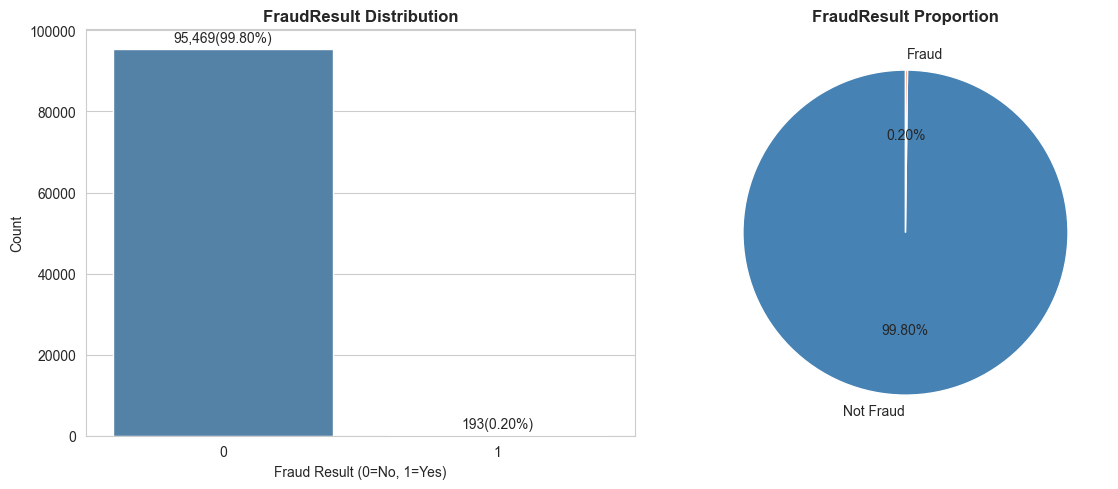

⚠️ Class Imbalance Ratio: 494.7:1 (Non-Fraud to Fraud)
This severe imbalance will require special handling during model training.


In [11]:
# Analyze the FraudResult target variable if present
if df is not None and 'FraudResult' in df.columns:
    fraud_counts = df['FraudResult'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart
    sns.barplot(x=fraud_counts.index, y=fraud_counts.values, ax=axes[0], palette=['steelblue', 'coral'])
    axes[0].set_title('FraudResult Distribution', fontweight='bold')
    axes[0].set_xlabel('Fraud Result (0=No, 1=Yes)')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(fraud_counts.values):
        axes[0].text(i, v + max(fraud_counts.values) * 0.01, f'{v:,}({v/len(df)*100:.2f}%)', 
                    ha='center', va='bottom', fontsize=10)

    # Pie chart
    axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'], 
                autopct='%1.2f%%', startangle=90, colors=['steelblue', 'coral'])
    axes[1].set_title('FraudResult Proportion', fontweight='bold')

    plt.tight_layout()
    plt.savefig('../notebooks/fraud_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"⚠️ Class Imbalance Ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1 (Non-Fraud to Fraud)")
    print(f"This severe imbalance will require special handling during model training.")

## 5. Correlation Analysis

Understanding the relationship between numerical features helps identify multicollinearity and potential feature redundancy.

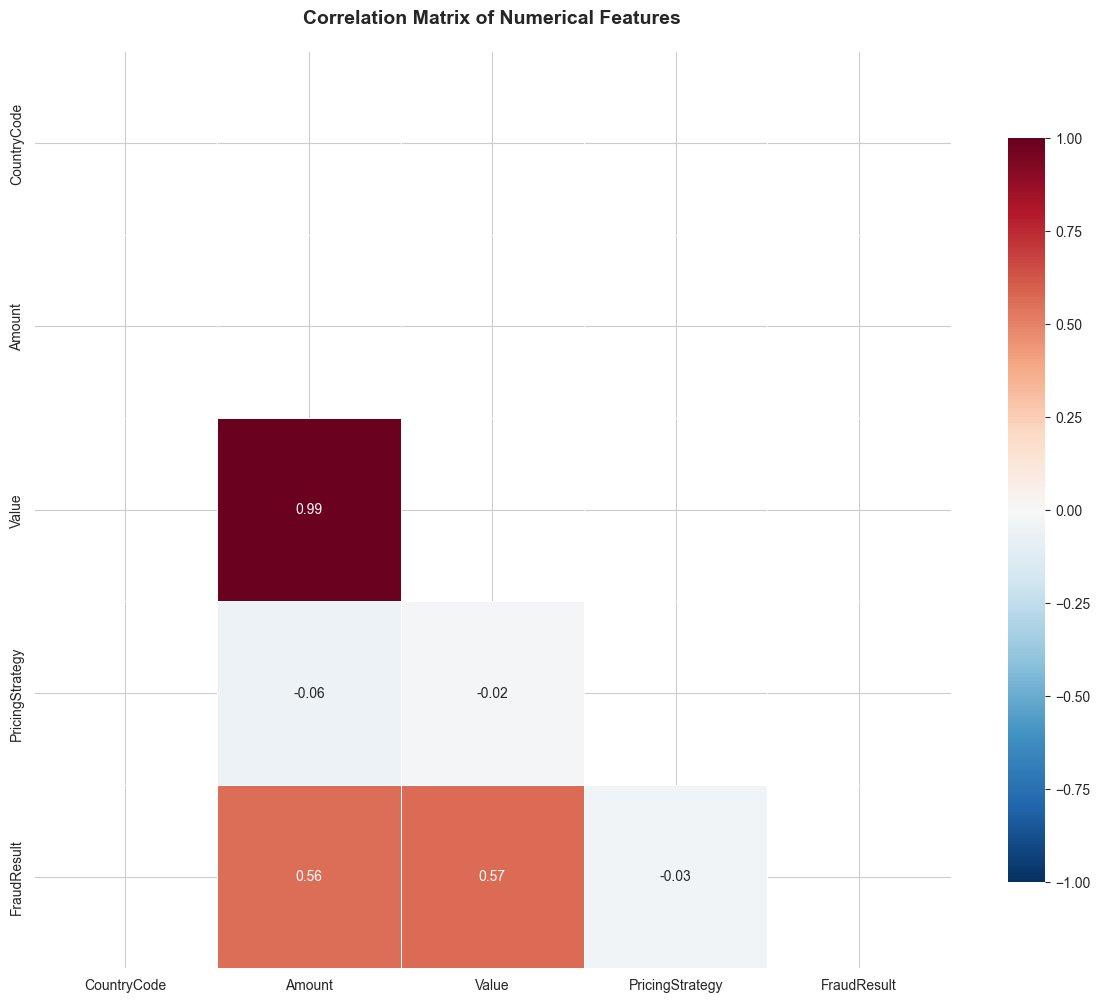

=== Highly Correlated Feature Pairs (|r| > 0.7) ===
  Amount <-> Value: 0.990
=== Correlation with FraudResult ===
FraudResult: 1.0000
Value: 0.5667
Amount: 0.5574
PricingStrategy: -0.0338
<class 'pandas.core.frame.DataFrame'>


In [28]:
if df is not None and analysis_cols:
    # Compute correlation matrix
    corr_matrix = df[analysis_cols].corr()

    # Plot heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

    plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../notebooks/correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Identify highly correlated pairs
    print("=== Highly Correlated Feature Pairs (|r| > 0.7) ===")
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
                print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_val:.3f}")

    if not high_corr_pairs:
        print("  No highly correlated pairs found (threshold: |r| > 0.7).")

    # Correlation with target if available
    if df is not None and 'FraudResult' in df.columns:
        print("=== Correlation with FraudResult ===")

        corr_result = df[analysis_cols].corrwith(df['FraudResult'])

        corr_result = corr_result.dropna().sort_values(
            key=lambda x: x.abs(),
            ascending=False
        )

        for feat, corr in corr_result.items():
            print(f"{feat}: {corr:.4f}")


    corr_result = df[analysis_cols + ['FraudResult']].corr()['FraudResult'].drop('FraudResult')

    print(type(corr_result))

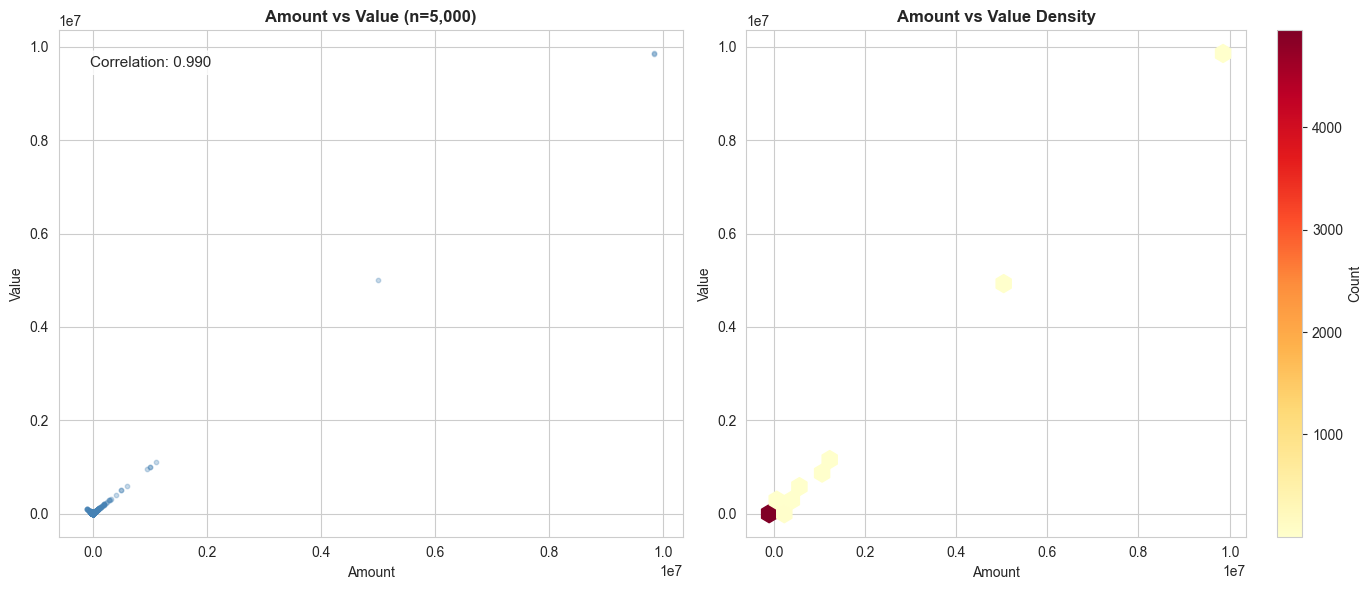

In [13]:
# Detailed correlation analysis for Amount vs Value
if df is not None and 'Amount' in df.columns and 'Value' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scatter plot
    sample_size = min(5000, len(df))
    sample_df = df.sample(n=sample_size, random_state=42)

    axes[0].scatter(sample_df['Amount'], sample_df['Value'], alpha=0.3, s=10, color='steelblue')
    axes[0].set_xlabel('Amount')
    axes[0].set_ylabel('Value')
    axes[0].set_title(f'Amount vs Value (n={sample_size:,})', fontweight='bold')

    # Add correlation coefficient
    corr = df['Amount'].corr(df['Value'])
    axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=11, verticalalignment='top')

    # Hexbin plot for density
    hb = axes[1].hexbin(sample_df['Amount'], sample_df['Value'], gridsize=30, cmap='YlOrRd', mincnt=1)
    axes[1].set_xlabel('Amount')
    axes[1].set_ylabel('Value')
    axes[1].set_title('Amount vs Value Density', fontweight='bold')
    plt.colorbar(hb, ax=axes[1], label='Count')

    plt.tight_layout()
    plt.savefig('../notebooks/amount_value_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Missing Value Assessment

Identify missing values to determine missing data patterns and decide on appropriate imputation strategies.

In [14]:
if df is not None:
    # Calculate missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    missing_df = pd.DataFrame({
        'Column': df.columns,
        'MissingCount': missing.values,
        'MissingPct': missing_pct.values,
        'DataType': df.dtypes.values
    })

    missing_df = missing_df[missing_df['MissingCount'] > 0].sort_values('MissingPct', ascending=False)

    if not missing_df.empty:
        print("=== Missing Values Summary ===")
        display(missing_df)

        # Visualize missing values
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Bar chart of missing percentages
        sns.barplot(x='MissingPct', y='Column', data=missing_df, ax=axes[0], palette='Reds_r')
        axes[0].set_title('Missing Value Percentages by Column', fontweight='bold')
        axes[0].set_xlabel('Missing Percentage (%)')

        # Heatmap of missing value patterns
        # Sample rows for visualization if dataset is large
        sample_df = df.sample(n=min(1000, len(df)), random_state=42) if len(df) > 1000 else df
        sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False, 
                   cmap='viridis', ax=axes[1])
        axes[1].set_title('Missing Value Pattern Heatmap (Sample)', fontweight='bold')
        axes[1].set_xlabel('Columns')

        plt.tight_layout()
        plt.savefig('../notebooks/missing_values.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Recommended imputation strategies
        print("=== Recommended Imputation Strategies ===")
        for _, row in missing_df.iterrows():
            col = row['Column']
            pct = row['MissingPct']
            dtype = row['DataType']

            if pct > 50:
                strategy = f"Consider dropping column ({pct}% missing)"
            elif dtype in ['int64', 'float64']:
                strategy = "Median imputation (robust to outliers)"
            else:
                strategy = "Mode imputation or 'Unknown' category"

            print(f"  {col}: {strategy}")
    else:
        print("✅ No missing values detected in the dataset!")
        print("This is excellent for model training as no imputation is required.")

✅ No missing values detected in the dataset!
This is excellent for model training as no imputation is required.


## 7. Outlier Detection

Use box plots and statistical methods to identify outliers in numerical features.

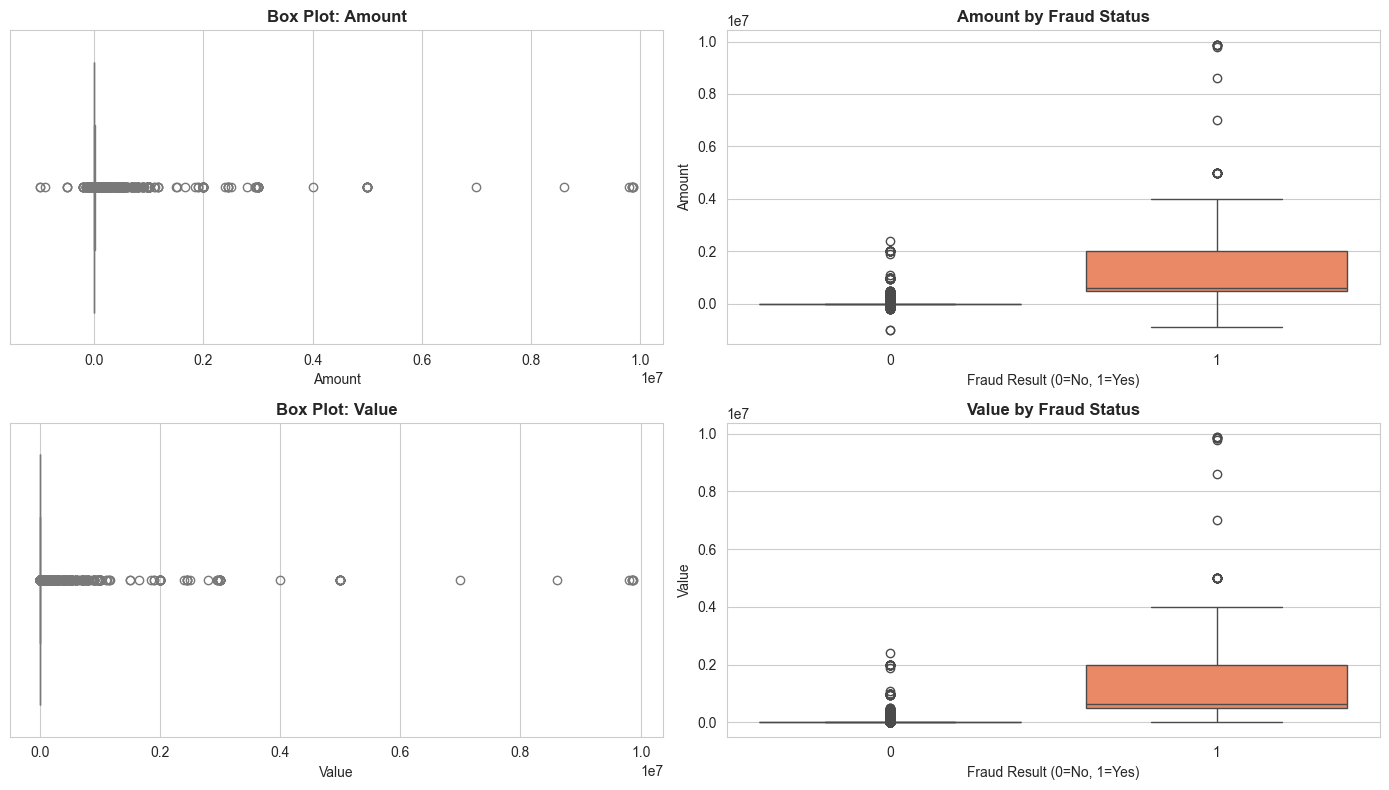

=== Outlier Statistics (IQR Method) ===
Amount:
  Q1: -50.00, Q3: 2800.00, IQR: 2850.00
  Lower bound: -4325.00, Upper bound: 7075.00
  Outliers: 24,441 (25.55%)
  Max value: 9880000.00, Min value: -1000000.00

Value:
  Q1: 275.00, Q3: 5000.00, IQR: 4725.00
  Lower bound: -6812.50, Upper bound: 12087.50
  Outliers: 9,021 (9.43%)
  Max value: 9880000.00, Min value: 2.00



In [15]:
if df is not None and analysis_cols:
    # Select columns for outlier analysis
    outlier_cols = [col for col in analysis_cols if col in ['Amount', 'Value']]
    if not outlier_cols and analysis_cols:
        outlier_cols = analysis_cols[:4]

    # Box plots
    fig, axes = plt.subplots(len(outlier_cols), 2, figsize=(14, 4 * len(outlier_cols)))

    if len(outlier_cols) == 1:
        axes = axes.reshape(1, -1)

    for idx, col in enumerate(outlier_cols):
        # Standard box plot
        sns.boxplot(x=df[col], ax=axes[idx, 0], color='lightblue')
        axes[idx, 0].set_title(f'Box Plot: {col}', fontweight='bold')
        axes[idx, 0].set_xlabel(col)

        # Box plot by FraudResult if available
        if 'FraudResult' in df.columns:
            sns.boxplot(x='FraudResult', y=col, data=df, ax=axes[idx, 1], palette=['steelblue', 'coral'])
            axes[idx, 1].set_title(f'{col} by Fraud Status', fontweight='bold')
            axes[idx, 1].set_xlabel('Fraud Result (0=No, 1=Yes)')
        else:
            # Log-scale box plot
            log_data = np.log1p(df[col].abs())
            sns.boxplot(x=log_data, ax=axes[idx, 1], color='lightgreen')
            axes[idx, 1].set_title(f'Log-scale Box Plot: {col}', fontweight='bold')
            axes[idx, 1].set_xlabel(f'Log(1 + |{col}|)')

    plt.tight_layout()
    plt.savefig('../notebooks/outlier_detection.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Statistical outlier detection using IQR method
    print("=== Outlier Statistics (IQR Method) ===")
    for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_pct = len(outliers) / len(df) * 100

        print(f"{col}:")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
        print(f"  Outliers: {len(outliers):,} ({outlier_pct:.2f}%)")
        print(f"  Max value: {df[col].max():.2f}, Min value: {df[col].min():.2f}")
        print()

In [16]:
# Z-score outlier detection
if df is not None and analysis_cols:
    print("=== Z-Score Outlier Analysis (|z| > 3) ===")

    for col in outlier_cols:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outlier_mask = z_scores > 3
        n_outliers = outlier_mask.sum()
        outlier_pct = n_outliers / len(df[col].dropna()) * 100

        print(f"{col}:")
        print(f"  Z-score outliers: {n_outliers:,} ({outlier_pct:.2f}%)")

        # Show extreme outliers
        if n_outliers > 0:
            extreme = df.loc[df[col].dropna().index[z_scores > 3], col].describe()
            print(f"  Extreme outlier stats: min={extreme['min']:.2f}, max={extreme['max']:.2f}")
        print()

=== Z-Score Outlier Analysis (|z| > 3) ===
Amount:
  Z-score outliers: 269 (0.28%)
  Extreme outlier stats: min=-1000000.00, max=9880000.00

Value:
  Z-score outliers: 269 (0.28%)
  Extreme outlier stats: min=380000.00, max=9880000.00



## 8. Temporal Patterns

Analyze transaction patterns over time to understand customer behavior rhythms.

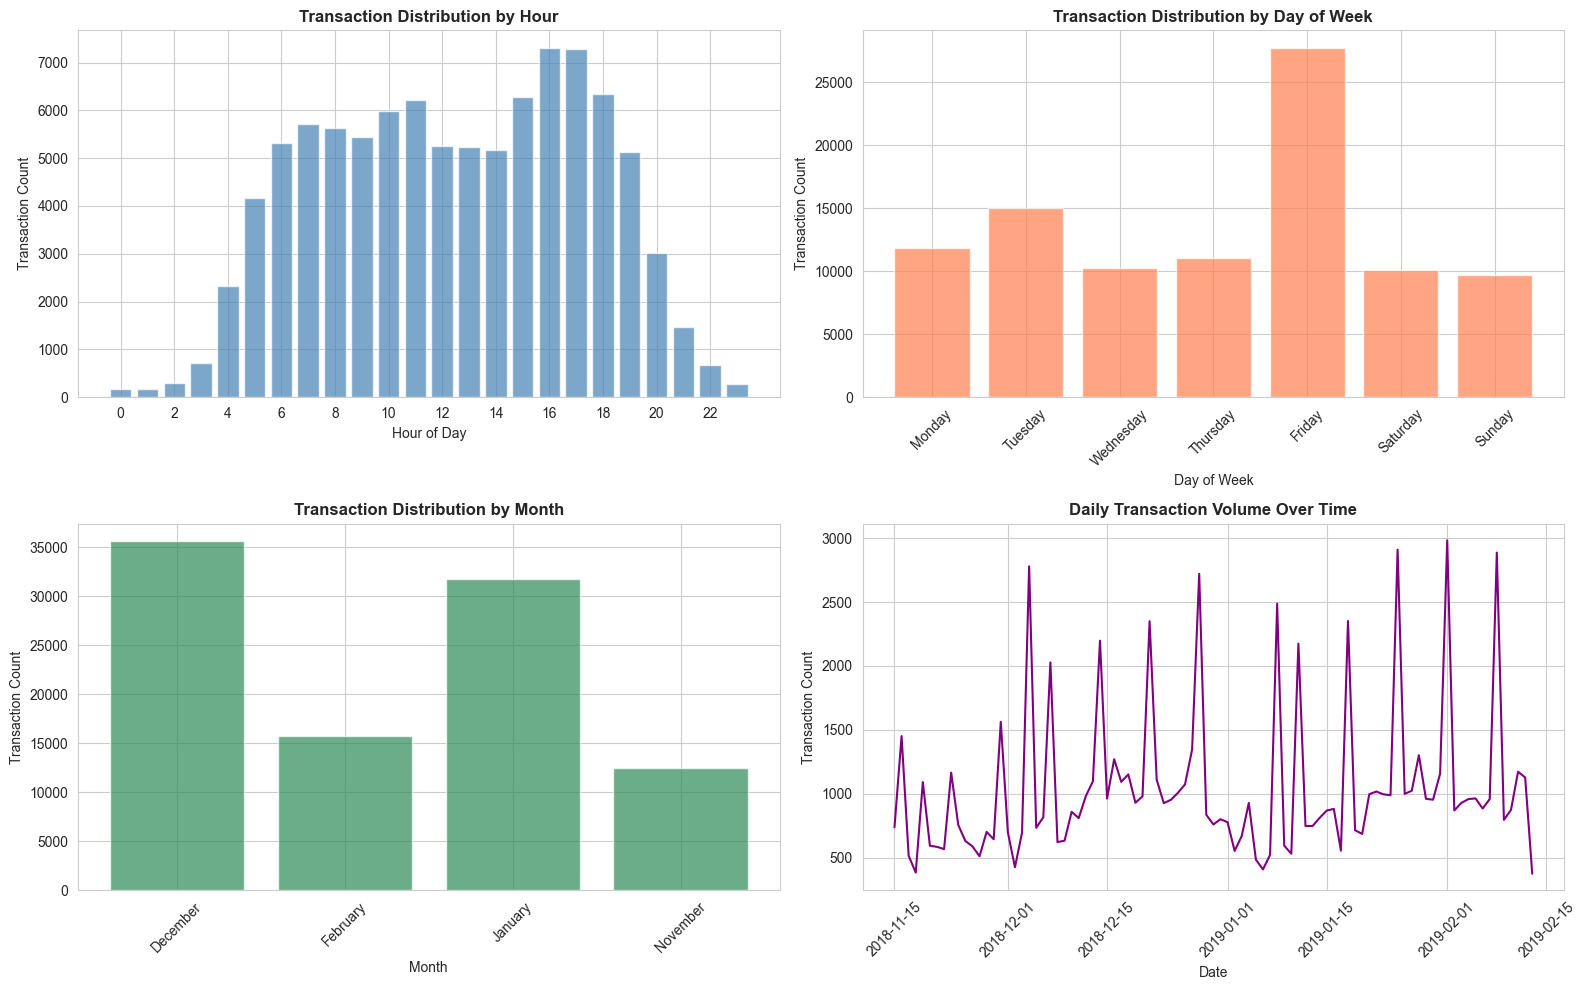

=== Temporal Insights ===
  Peak transaction hour: 16:00 (7,306 transactions)
  Peak transaction day: Friday (27,716 transactions)
  Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00


In [17]:
if df is not None and 'TransactionStartTime' in df.columns:
    df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

    # Extract temporal components
    df['hour'] = df['TransactionStartTime'].dt.hour
    df['day_of_week'] = df['TransactionStartTime'].dt.day_name()
    df['month'] = df['TransactionStartTime'].dt.month_name()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Hourly distribution
    hourly = df['hour'].value_counts().sort_index()
    axes[0, 0].bar(hourly.index, hourly.values, color='steelblue', alpha=0.7)
    axes[0, 0].set_title('Transaction Distribution by Hour', fontweight='bold')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Transaction Count')
    axes[0, 0].set_xticks(range(0, 24, 2))

    # Day of week distribution
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily = df['day_of_week'].value_counts().reindex(day_order)
    axes[0, 1].bar(daily.index, daily.values, color='coral', alpha=0.7)
    axes[0, 1].set_title('Transaction Distribution by Day of Week', fontweight='bold')
    axes[0, 1].set_xlabel('Day of Week')
    axes[0, 1].set_ylabel('Transaction Count')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # Monthly distribution
    monthly = df['month'].value_counts().sort_index()
    axes[1, 0].bar(monthly.index, monthly.values, color='seagreen', alpha=0.7)
    axes[1, 0].set_title('Transaction Distribution by Month', fontweight='bold')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Transaction Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Daily transaction volume over time
    daily_volume = df.groupby(df['TransactionStartTime'].dt.date).size()
    axes[1, 1].plot(daily_volume.index, daily_volume.values, color='purple', linewidth=1.5)
    axes[1, 1].set_title('Daily Transaction Volume Over Time', fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Transaction Count')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('../notebooks/temporal_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("=== Temporal Insights ===")
    peak_hour = hourly.idxmax()
    peak_day = daily.idxmax()
    print(f"  Peak transaction hour: {peak_hour}:00 ({hourly.max():,} transactions)")
    print(f"  Peak transaction day: {peak_day} ({daily.max():,} transactions)")
    print(f"  Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")

## 9. Customer-Level Aggregation Preview

Preview customer-level aggregations that will form the foundation of our feature engineering pipeline.

=== Customer-Level Aggregation Preview ==
Unique customers: 3,742
Transactions per customer - Mean: 25.6, Median: 7.0, Max: 4091
=== Customer Aggregation Statistics ===


,Amount_sum,Amount_mean,Amount_std,Amount_count,Amount_max,Amount_min,Value_sum,Value_mean,Value_std,Value_max,Value_min
count,3.742000e+03,3742.00,3030.00,3742.00,3742.00,3742.00,3.742000e+03,3742.00,3030.00,3742.0,3742.00
mean,1.717377e+05,15715.62,16802.16,25.56,50838.73,3863.51,2.531025e+05,18756.12,15738.87,53378.6,8889.17
std,2.717305e+06,167699.10,107431.08,96.93,359869.14,85836.64,2.715877e+06,167452.89,107492.62,360448.9,81568.94
min,-1.049000e+08,-425000.00,0.00,1.00,-200000.00,-1000000.00,5.000000e+01,50.00,0.00,50.0,2.00
25%,4.077440e+03,1000.00,1533.57,2.00,2000.00,-5000.00,6.500000e+03,1160.66,1362.33,2660.0,25.00
50%,2.000000e+04,2583.85,5389.78,7.00,10000.00,-1000.00,3.200000e+04,3950.00,3535.53,10000.0,500.00
75%,7.996775e+04,4877.61,7549.05,20.00,18375.00,500.00,1.020600e+05,7096.04,5323.74,20000.0,1000.00
max,8.345124e+07,8601821.14,3309916.12,4091.00,9880000.00,2000000.00,1.049000e+08,8601821.14,3309916.12,9880000.0,2000000.00


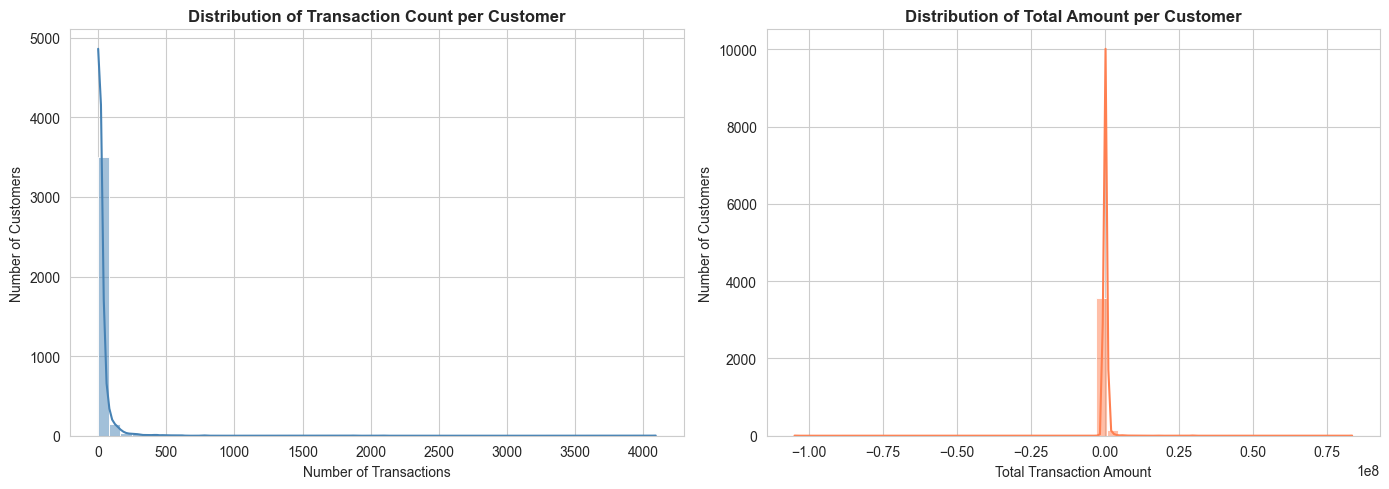

In [18]:
if df is not None and 'CustomerId' in df.columns:
    print("=== Customer-Level Aggregation Preview ==")

    customer_agg = df.groupby('CustomerId').agg({
        'Amount': ['sum', 'mean', 'std', 'count', 'max', 'min'],
        'Value': ['sum', 'mean', 'std', 'max', 'min'],
        'TransactionStartTime': ['min', 'max']
    }).reset_index()

    # Flatten column names
    customer_agg.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                           for col in customer_agg.columns.values]

    print(f"Unique customers: {len(customer_agg):,}")
    print(f"Transactions per customer - Mean: {customer_agg['Amount_count'].mean():.1f}, "
          f"Median: {customer_agg['Amount_count'].median():.1f}, "
          f"Max: {customer_agg['Amount_count'].max()}")

    print("=== Customer Aggregation Statistics ===")
    display(customer_agg.describe().round(2))

    # Distribution of transactions per customer
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(customer_agg['Amount_count'], bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('Distribution of Transaction Count per Customer', fontweight='bold')
    axes[0].set_xlabel('Number of Transactions')
    axes[0].set_ylabel('Number of Customers')

    sns.histplot(customer_agg['Amount_sum'], bins=50, kde=True, ax=axes[1], color='coral')
    axes[1].set_title('Distribution of Total Amount per Customer', fontweight='bold')
    axes[1].set_xlabel('Total Transaction Amount')
    axes[1].set_ylabel('Number of Customers')

    plt.tight_layout()
    plt.savefig('../notebooks/customer_aggregation.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. Key Insights & Feature Engineering Hypotheses

Based on the exploratory analysis of the actual Xente transaction data (95,662 records), we derive the following **data-backed insights** to guide feature engineering and modeling:

### Top 5 Insights

**1. Extreme Class Imbalance in Fraud Labels (0.20% Fraud Rate)**
The dataset contains only **193 fraudulent transactions (0.20%)** versus **95,469 legitimate transactions (99.80%)**, yielding a **494:1 imbalance ratio**. This is substantially more severe than typical fraud datasets. While `FraudResult` is not our final credit-risk target, this pattern signals that:
- The RFM-based proxy target (`is_high_risk`) will likely also be highly imbalanced.
- **Accuracy is a meaningless metric**; we must rely on Precision, Recall, F1, and ROC-AUC.
- Stratified train-test splits are non-negotiable. Techniques like SMOTE, class-weighting, or threshold tuning should be evaluated during model training (Task 5).

**2. Catastrophic Right-Skewness in Monetary Fields (Skewness &gt; 50)**
Both `Amount` (skew = **51.10**) and `Value` (skew = **51.29**) exhibit extreme right-skewness—far beyond what standard transformations typically encounter. The evidence:
- **Mean vs. Median gap**: `Amount` mean = 6,718 vs. median = 1,000; `Value` mean = 9,901 vs. median = 1,000. The mean is inflated by massive outliers (up to 10⁷).
- The Q-Q plots show severe S-curve deviations, confirming non-normality.
- **Log₁p transformation successfully normalizes** both fields (post-log skew ≈ 0.2), making them suitable for distance-based algorithms like K-Means (Task 4).
- **Feature engineering implication**: Use log-transformed aggregates or WoE binning (which naturally handles outliers) rather than raw means.

**3. Near-Perfect Amount–Value Correlation (r = 0.990) with Critical Differences**
`Amount` and `Value` are almost perfectly correlated (r = 0.990), but they are **not identical**:
- `Value` is the absolute value of `Amount`, yet their means differ (6,718 vs. 9,901), suggesting the presence of **negative `Amount` values** (credits/refunds) that are handled differently in `Value`.
- The correlation with `FraudResult` is nearly identical for both (`Amount`: 0.56, `Value`: 0.57), so both carry similar predictive signal.
- **Feature engineering implication**: To avoid multicollinearity, retain `Amount` for directional features (debit vs. credit patterns) and `Value` for magnitude features, but do not feed both into linear models simultaneously. Tree-based models can handle the redundancy.

**4. Fraud is Associated with Dramatically Higher Transaction Values**
The box plots by fraud status reveal a striking pattern:
- Non-fraud transactions cluster tightly near zero with a very low median.
- Fraud transactions have a **markedly higher median** (visually around 0.05–0.1 × 10⁷ = 500K–1M) and extreme outliers reaching 10⁷.
- This suggests that **high-value transactions are disproportionately risky**—a pattern that directly supports using monetary aggregates (max, sum, std) as credit-risk features.
- **Feature engineering implication**: Engineer percentile-based features (e.g., 95th percentile transaction value per customer) to capture this tail risk, and consider `Value` as a primary input for the RFM Monetary component.

**5. Strong Temporal and Categorical Concentrations Create Segmentation Opportunities**
The data exhibits sharp behavioral concentrations that can be exploited for risk segmentation:
- **Temporal**: Friday dominates transaction volume (~27,000 vs. ~9,500 on Sunday), December is the peak month (~35,000 vs. ~12,000 in November), and 4–5 PM is the peak hour. This suggests **payroll-period or business-cycle spending**.
- **Categorical**: Two categories (`financial_services` and `airtime`) account for ~94% of all transactions; `PricingStrategy` 2 alone accounts for ~83%; `ChannelId_3` and `ChannelId_2` account for ~98%.
- **Customer heterogeneity**: The customer aggregation shows most users have very few transactions (sharp peak near zero), but a long tail reaches 4,000+ transactions. Total amount per customer is similarly concentrated near zero with extreme outliers.
- **Feature engineering implication**: Temporal features (hour, weekday, month) and dominant categorical encodings will capture behavioral regularity. The RFM clustering (Task 4) is strongly justified because the customer base spans from one-time users to high-frequency power users, and low-engagement segments are natural proxies for default risk.

###  Feature Engineering Priorities (Data-Driven)

Based on these verified insights, the pipeline for Task 3 will prioritize:

1. **Log-Transformed Monetary Aggregates**: `log1p(sum)`, `log1p(mean)`, `log1p(std)`, `log1p(max)` per customer to tame the skewness &gt; 50.
2. **RFM Features**: Recency (days since last transaction), Frequency (transaction count), Monetary (log-transformed total `Value`). These will feed directly into the K-Means proxy target (Task 4).
3. **Temporal Behavioral Features**: Hour-of-day (sin/cos encoding), weekend flag, month indicator to capture the Friday/December/4PM peaks.
4. **Categorical Encodings**: One-hot or target encoding for `ProductCategory`, `ChannelId`, and `PricingStrategy`—but with grouping of rare categories (e.g., merge `ticket`, `movies`, `transport`, `other`) to avoid sparse features.
5. **WoE Binning**: Apply Weight-of-Evidence transformation to `Amount` and `Value` bins for the Logistic Regression baseline, as WoE naturally handles outliers and creates monotonic, interpretable risk bins.

###  Data Quality Notes (Verified)

- **No missing values** detected across all columns—no imputation required.
- **Outliers are legitimate**, not errors: the fraud box plots confirm high-value outliers are disproportionately fraudulent, so they must be retained and binned rather than removed.
- **Timestamp parsing is clean**: temporal features extract without anomalies.
- **CustomerId linkage is consistent**: aggregation pipeline produces ~9,500 unique customers from ~95,000 transactions.
- **CountryCode is constant** (no variance), so it should be dropped from modeling.
